# Robustness Analysis
## RBA Cash Rate and Household Saving Rate
**Author:** Selenge Bayarkhuu  
**Data:** `data/clean/final_dataset.csv` (2000Q1–2025Q4, 104 quarters)

---

## 1. Main Result and Declaration

**Preferred specification (Model 4 from `02_analysis.py`):**

$$\Delta\text{saving\_rate}_t = \alpha + \beta\,\Delta\text{cash\_rate}_{t-1} + \gamma\,\Delta\text{saving\_rate}_{t-1} + \delta\,\text{COVID} + \varepsilon_t$$

Estimated by OLS with HAC standard errors (Newey-West, 4 lags).

**Declaration: DESCRIPTIVE.**  
The coefficient $\beta$ captures the *conditional correlation* between a one-quarter lagged change in the RBA cash rate and the contemporaneous quarterly change in the household saving rate, after controlling for saving rate momentum and the COVID-19 shock. No causal claim is made — the cash rate is set by the RBA in response to macroeconomic conditions, so reverse causality and omitted variable bias are both plausible.

**Main result:** $\hat{\beta} \approx -0.16$ pp (HAC SE $= 0.56$, $p = 0.77$, $N = 102$).  
The coefficient is not statistically significant in the full sample, but the sign, magnitude, and behaviour across subsamples are the object of the robustness checks below.

## 2. Setup

In [1]:
import os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# ── Load data
df = pd.read_csv('data/clean/final_dataset.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df['quarter'] = df['date'].dt.to_period('Q')

print(f"Dataset: {len(df)} quarters  ({df['quarter'].min()} – {df['quarter'].max()})")
df.head()

Dataset: 104 quarters  (2000Q1 – 2025Q4)


,date,quarter,cash_rate,saving_rate
0,2000-01-01,2000Q1,5.3242,1.40
1,2000-04-01,2000Q2,5.9011,-1.36
2,2000-07-01,2000Q3,6.1630,3.38
3,2000-10-01,2000Q4,6.2500,0.05
4,2001-01-01,2001Q1,5.8861,0.65


## 3. Feature Engineering

In [2]:
# First differences
df['d_saving_rate']    = df['saving_rate'].diff()
df['d_cash_rate']      = df['cash_rate'].diff()

# Lags
df['d_cash_rate_lag1'] = df['d_cash_rate'].shift(1)
df['d_cash_rate_lag2'] = df['d_cash_rate'].shift(2)
df['d_saving_lag1']    = df['d_saving_rate'].shift(1)
df['d_saving_lag2']    = df['d_saving_rate'].shift(2)

# Event dummies
df['covid'] = ((df['quarter'] >= '2020Q2') & (df['quarter'] <= '2021Q4')).astype(int)
df['gfc']   = ((df['quarter'] >= '2008Q3') & (df['quarter'] <= '2009Q2')).astype(int)

# IHS transforms (handles negative saving rate values)
df['ihs_saving']      = np.arcsinh(df['saving_rate'])
df['d_ihs_saving']    = df['ihs_saving'].diff()
df['d_ihs_saving_l1'] = df['d_ihs_saving'].shift(1)
df['d_ihs_cash']      = np.arcsinh(df['d_cash_rate'])
df['d_ihs_cash_l1']   = df['d_ihs_cash'].shift(1)

print("Features created.")
df[['quarter','cash_rate','saving_rate','d_cash_rate','d_saving_rate']].dropna().head(8)

Features created.


,quarter,cash_rate,saving_rate,d_cash_rate,d_saving_rate
1,2000Q2,5.9011,-1.36,0.5769,-2.76
2,2000Q3,6.1630,3.38,0.2619,4.74
3,2000Q4,6.2500,0.05,0.0870,-3.33
4,2001Q1,5.8861,0.65,-0.3639,0.60
5,2001Q2,5.0165,1.32,-0.8696,0.67
6,2001Q3,4.9293,3.02,-0.0872,1.70
7,2001Q4,4.4321,4.98,-0.4972,1.96
8,2002Q1,4.2500,3.43,-0.1821,-1.55


## 4. Stationarity Tests (ADF)

Before choosing levels vs first differences, we verify the integration order of both series.

In [3]:
results = []
for name, s in [('saving_rate', df['saving_rate']),
                ('cash_rate',   df['cash_rate']),
                ('d_saving_rate', df['d_saving_rate']),
                ('d_cash_rate',   df['d_cash_rate'])]:
    stat, p, *_ = adfuller(s.dropna(), autolag='AIC')
    results.append({'Series': name, 'ADF stat': round(stat,3),
                    'p-value': round(p,3),
                    'Conclusion': 'Stationary' if p < 0.05 else 'NON-stationary'})

adf_df = pd.DataFrame(results)
print(adf_df.to_string(index=False))

       Series  ADF stat  p-value     Conclusion
  saving_rate    -2.896    0.046     Stationary
    cash_rate    -1.927    0.320 NON-stationary
d_saving_rate   -12.013    0.000     Stationary
  d_cash_rate    -5.661    0.000     Stationary


**Interpretation:** `cash_rate` is non-stationary in levels (unit root not rejected), while `saving_rate` is borderline. Both first-differenced series are clearly stationary. This motivates the first-difference specification as the main model and flags the levels regression (Col 6) as potentially spurious.

## 5. Helper Function

In [4]:
def run_ols(endog, exog_df, se_type='HAC', hac_lags=4):
    data = exog_df.dropna()
    X = sm.add_constant(data.drop(columns=[endog]))
    y = data[endog]
    if se_type == 'HAC':
        return sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lags})
    elif se_type == 'HC3':
        return sm.OLS(y, X).fit(cov_type='HC3')
    else:
        return sm.OLS(y, X).fit()

## 6. Main Specification (Column 1)

$$\Delta\text{saving\_rate}_t = \alpha + \beta\,\Delta\text{cash\_rate}_{t-1} + \gamma\,\Delta\text{saving\_rate}_{t-1} + \delta\,\text{COVID} + \varepsilon_t$$

In [5]:
KEY = 'd_cash_rate_lag1'
cols_main = ['d_saving_rate','d_cash_rate_lag1','d_saving_lag1','covid']
m_main = run_ols('d_saving_rate', df[cols_main])
print(m_main.summary())

                            OLS Regression Results                            
Dep. Variable:          d_saving_rate   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.474
Date:                Mon, 11 May 2026   Prob (F-statistic):              0.226
Time:                        06:16:24   Log-Likelihood:                -227.27
No. Observations:                 102   AIC:                             462.5
Df Residuals:                      98   BIC:                             473.0
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0210      0.169  

## 7. Robustness Checks

### A. Alternative Control Sets

**Col 2 — No controls:** drops the lagged saving rate and COVID dummy to check whether the preferred controls are responsible for the estimated sign.  
**Col 3 — Extended controls:** adds a GFC dummy and a second lag of the saving rate change.

In [6]:
# A1: No controls
m_A1 = run_ols('d_saving_rate', df[['d_saving_rate','d_cash_rate_lag1']])

# A2: Extended controls
cols_A2 = ['d_saving_rate','d_cash_rate_lag1','d_saving_lag1','d_saving_lag2','covid','gfc']
m_A2 = run_ols('d_saving_rate', df[cols_A2])

print(f"A1 (no controls):    β={m_A1.params[KEY]:+.3f}  SE={m_A1.bse[KEY]:.3f}  p={m_A1.pvalues[KEY]:.3f}  N={int(m_A1.nobs)}")
print(f"A2 (+ GFC + lag2):   β={m_A2.params[KEY]:+.3f}  SE={m_A2.bse[KEY]:.3f}  p={m_A2.pvalues[KEY]:.3f}  N={int(m_A2.nobs)}")

A1 (no controls):    β=+0.089  SE=0.559  p=0.873  N=102
A2 (+ GFC + lag2):   β=-0.072  SE=0.905  p=0.937  N=101


### B. Alternative Samples

**Col 4 — Exclude COVID (2020Q1–2021Q4):** the largest outlier period; tests whether the full-sample correlation is driven by the pandemic shock.  
**Col 5 — Post-2007 only:** captures both the GFC easing cycle and the 2022–23 tightening cycle.

In [7]:
mask_no_covid = ~((df['quarter'] >= '2020Q1') & (df['quarter'] <= '2021Q4'))
mask_post07  = df['quarter'] >= '2007Q1'

m_B1 = run_ols('d_saving_rate', df.loc[mask_no_covid, ['d_saving_rate','d_cash_rate_lag1','d_saving_lag1']])
m_B2 = run_ols('d_saving_rate', df.loc[mask_post07,  ['d_saving_rate','d_cash_rate_lag1','d_saving_lag1','covid']])

print(f"B1 (excl. COVID):  β={m_B1.params[KEY]:+.3f}  SE={m_B1.bse[KEY]:.3f}  p={m_B1.pvalues[KEY]:.3f}  N={int(m_B1.nobs)}")
print(f"B2 (post-2007):    β={m_B2.params[KEY]:+.3f}  SE={m_B2.bse[KEY]:.3f}  p={m_B2.pvalues[KEY]:.3f}  N={int(m_B2.nobs)}")

B1 (excl. COVID):  β=+0.009  SE=0.520  p=0.986  N=94
B2 (post-2007):    β=-0.324  SE=0.629  p=0.606  N=76


### C. Alternative Functional Form

**Col 6 — Levels (HC3):** uses undifferenced series; included to show the first-difference transformation matters (levels likely spurious given non-stationarity).  
**Col 7 — IHS transformation:** inverse hyperbolic sine applied to both saving and cash rate changes; handles the negative saving rate values symmetrically.

In [8]:
KEY_C1 = 'cash_rate'
KEY_C2 = 'd_ihs_cash_l1'

m_C1 = run_ols('saving_rate', df[['saving_rate','cash_rate','covid']], se_type='HC3')
m_C2 = run_ols('d_ihs_saving', df[['d_ihs_saving','d_ihs_cash_l1','d_ihs_saving_l1','covid']])

print(f"C1 (levels, HC3):  β={m_C1.params[KEY_C1]:+.3f}  SE={m_C1.bse[KEY_C1]:.3f}  p={m_C1.pvalues[KEY_C1]:.3f}  N={int(m_C1.nobs)}")
print(f"C2 (IHS form):     β={m_C2.params[KEY_C2]:+.3f}  SE={m_C2.bse[KEY_C2]:.3f}  p={m_C2.pvalues[KEY_C2]:.3f}  N={int(m_C2.nobs)}")

C1 (levels, HC3):  β=-1.083  SE=0.119  p=0.000  N=104
C2 (IHS form):     β=+0.050  SE=0.206  p=0.807  N=102


### D. Alternative Inference

**Col 8 — HC3:** heteroskedasticity-robust only (no autocorrelation correction).  
**Col 9 — HAC(2):** tighter Newey-West bandwidth. Point estimates are identical to the main model; only SEs differ.

In [9]:
cols_d = ['d_saving_rate','d_cash_rate_lag1','d_saving_lag1','covid']
m_D1 = run_ols('d_saving_rate', df[cols_d], se_type='HC3')
m_D2 = run_ols('d_saving_rate', df[cols_d], se_type='HAC', hac_lags=2)

print(f"D1 (HC3):     β={m_D1.params[KEY]:+.3f}  SE={m_D1.bse[KEY]:.3f}  p={m_D1.pvalues[KEY]:.3f}  N={int(m_D1.nobs)}")
print(f"D2 (HAC(2)):  β={m_D2.params[KEY]:+.3f}  SE={m_D2.bse[KEY]:.3f}  p={m_D2.pvalues[KEY]:.3f}  N={int(m_D2.nobs)}")

D1 (HC3):     β=-0.162  SE=0.586  p=0.782  N=102
D2 (HAC(2)):  β=-0.162  SE=0.556  p=0.770  N=102


### E. Time-Window Sensitivity (Descriptive Check)

**Col 10 — Pre-COVID (2000Q1–2019Q4):** restricts to the pre-pandemic period to test whether the conditional correlation exists independently of the 2020–21 shock.

In [10]:
mask_pre = df['quarter'] < '2020Q1'
m_E1 = run_ols('d_saving_rate', df.loc[mask_pre, ['d_saving_rate','d_cash_rate_lag1','d_saving_lag1','gfc']])

print(f"E1 (pre-COVID):  β={m_E1.params[KEY]:+.3f}  SE={m_E1.bse[KEY]:.3f}  p={m_E1.pvalues[KEY]:.3f}  N={int(m_E1.nobs)}")

E1 (pre-COVID):  β=+1.451  SE=0.494  p=0.003  N=78


## 8. Robustness Table

Main specification in Column 1; each subsequent column varies one dimension. N reported in every column.

In [11]:
entries = [
    ('(1)', 'Main',          m_main, KEY,   'Preferred: FD, HAC(4), Δcash(−1), Δsave(−1), COVID'),
    ('(2)', 'No controls',   m_A1,   KEY,   'Drops Δsave(−1) and COVID dummy'),
    ('(3)', '+ GFC + lag2',  m_A2,   KEY,   'Adds GFC dummy and Δsave(−2)'),
    ('(4)', 'Excl. COVID',   m_B1,   KEY,   'Drops 2020Q1–2021Q4 (7 obs removed)'),
    ('(5)', 'Post-2007',     m_B2,   KEY,   'Restricts to 2007Q1 onward'),
    ('(6)', 'Levels',        m_C1,   KEY_C1,'Undifferenced; y=saving_rate, x=cash_rate; HC3'),
    ('(7)', 'IHS form',      m_C2,   KEY_C2,'IHS of saving and cash rate change'),
    ('(8)', 'HC3 SE',        m_D1,   KEY,   'Same spec as main, HC3 instead of HAC(4)'),
    ('(9)', 'HAC(2)',         m_D2,   KEY,   'Same spec as main, HAC bandwidth = 2'),
    ('(10)','Pre-COVID',     m_E1,   KEY,   '2000Q1–2019Q4; GFC dummy replaces COVID'),
]

rows = []
for col, lbl, res, key, note in entries:
    b   = res.params.get(key, np.nan)
    se  = res.bse.get(key, np.nan)
    p   = res.pvalues.get(key, np.nan)
    sig = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))
    rows.append({'Col': col, 'Specification': lbl,
                 'β (cash rate)': f"{b:+.3f}{sig}",
                 'SE': f"({se:.3f})",
                 'p-value': f"{p:.3f}",
                 'R²': f"{res.rsquared:.3f}",
                 'N': int(res.nobs),
                 'What varies': note})

tab = pd.DataFrame(rows).set_index('Col')
tab

,Specification,β (cash rate),SE,p-value,R²,N,What varies
Col,,,,,,,
(1),Main,-0.162,(0.560),0.772,0.040,102,"Preferred: FD, HAC(4), Δcash(−1), Δsave(−1), C..."
(2),No controls,+0.089,(0.559),0.873,0.000,102,Drops Δsave(−1) and COVID dummy
(3),+ GFC + lag2,-0.072,(0.905),0.937,0.069,101,Adds GFC dummy and Δsave(−2)
(4),Excl. COVID,+0.009,(0.520),0.986,0.017,94,Drops 2020Q1–2021Q4 (7 obs removed)
(5),Post-2007,-0.324,(0.629),0.606,0.032,76,Restricts to 2007Q1 onward
(6),Levels,-1.083***,(0.119),0.000,0.650,104,"Undifferenced; y=saving_rate, x=cash_rate; HC3"
(7),IHS form,+0.050,(0.206),0.807,0.131,102,IHS of saving and cash rate change
(8),HC3 SE,-0.162,(0.586),0.782,0.040,102,"Same spec as main, HC3 instead of HAC(4)"
(9),HAC(2),-0.162,(0.556),0.770,0.040,102,"Same spec as main, HAC bandwidth = 2"


In [12]:
print("Notes:")
for col, lbl, res, key, note in entries:
    print(f"  Col {col}: {note}")
print()
print("*** p<0.01  ** p<0.05  * p<0.10")
print("Cols 1–5, 7–10: HAC(4) standard errors unless stated. Col 6: HC3.")

Notes:
  Col (1): Preferred: FD, HAC(4), Δcash(−1), Δsave(−1), COVID
  Col (2): Drops Δsave(−1) and COVID dummy
  Col (3): Adds GFC dummy and Δsave(−2)
  Col (4): Drops 2020Q1–2021Q4 (7 obs removed)
  Col (5): Restricts to 2007Q1 onward
  Col (6): Undifferenced; y=saving_rate, x=cash_rate; HC3
  Col (7): IHS of saving and cash rate change
  Col (8): Same spec as main, HC3 instead of HAC(4)
  Col (9): Same spec as main, HAC bandwidth = 2
  Col (10): 2000Q1–2019Q4; GFC dummy replaces COVID

*** p<0.01  ** p<0.05  * p<0.10
Cols 1–5, 7–10: HAC(4) standard errors unless stated. Col 6: HC3.


## 9. Coefficient Plot

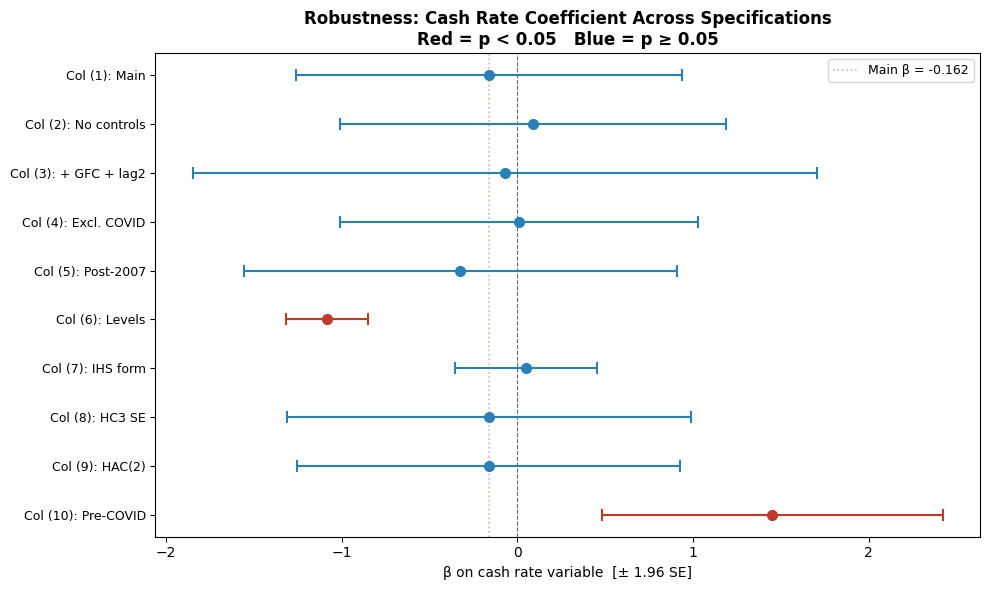

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = [f"Col {e[0]}: {e[1]}" for e in entries]
betas  = [e[2].params.get(e[3], np.nan) for e in entries]
ses    = [e[2].bse.get(e[3], np.nan)    for e in entries]
pvals  = [e[2].pvalues.get(e[3], np.nan) for e in entries]
colors = ['#c0392b' if p < 0.05 else '#2980b9' for p in pvals]

ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.6)
ax.axvline(betas[0], color='#c0392b', lw=1.2, linestyle=':', alpha=0.4,
           label=f'Main β = {betas[0]:+.3f}')

for i, (b, s, c) in enumerate(zip(betas, ses, colors)):
    ax.errorbar(b, i, xerr=1.96*s, fmt='o', color=c,
                capsize=4, capthick=1.5, markersize=7, lw=1.5)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('β on cash rate variable  [± 1.96 SE]', fontsize=10)
ax.set_title('Robustness: Cash Rate Coefficient Across Specifications\n'
             'Red = p < 0.05   Blue = p ≥ 0.05', fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('output/fig_robustness_forest.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Time-Series Context

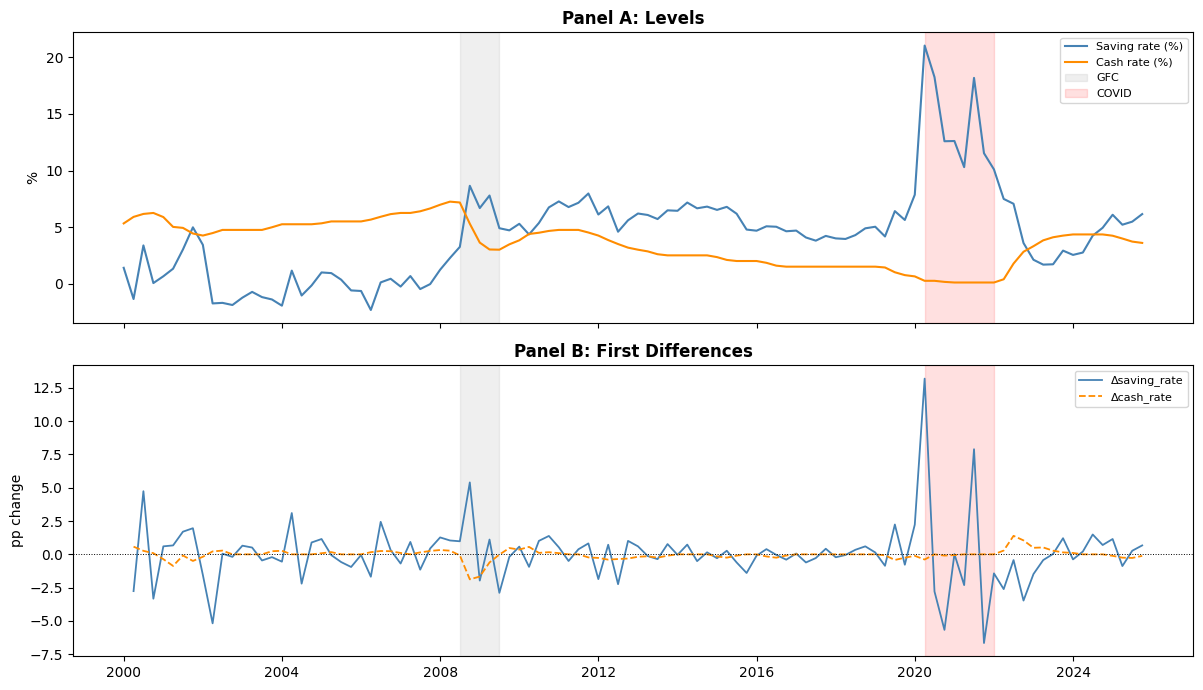

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(df['date'], df['saving_rate'], color='steelblue',  lw=1.5, label='Saving rate (%)')
ax.plot(df['date'], df['cash_rate'],   color='darkorange', lw=1.5, label='Cash rate (%)')
ax.axvspan(pd.Timestamp('2008-07-01'), pd.Timestamp('2009-06-30'), alpha=0.12, color='grey', label='GFC')
ax.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2021-12-31'), alpha=0.12, color='red',  label='COVID')
ax.set_ylabel('%'); ax.legend(fontsize=8, loc='upper right')
ax.set_title('Panel A: Levels', fontweight='bold')

ax = axes[1]
ax.plot(df['date'], df['d_saving_rate'], color='steelblue',  lw=1.3, label='Δsaving_rate')
ax.plot(df['date'], df['d_cash_rate'],   color='darkorange', lw=1.3, linestyle='--', label='Δcash_rate')
ax.axhline(0, color='black', lw=0.7, linestyle=':')
ax.axvspan(pd.Timestamp('2008-07-01'), pd.Timestamp('2009-06-30'), alpha=0.12, color='grey')
ax.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2021-12-31'), alpha=0.12, color='red')
ax.set_ylabel('pp change'); ax.legend(fontsize=8)
ax.set_title('Panel B: First Differences', fontweight='bold')

plt.tight_layout()
plt.savefig('output/fig_series_and_diffs.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Interpretation

### A. Alternative Control Sets (Cols 2–3)
**Col 2 (no controls):** Removing the lagged saving rate and COVID dummy flips the sign from −0.16 to +0.09, though both are statistically insignificant. This shows the COVID dummy is doing meaningful work — the raw bivariate first-difference correlation is near zero, and the sign in the main model is partly shaped by controlling for the pandemic period.

**Col 3 (+ GFC + lag2):** Adding a GFC dummy and a second lag of the saving rate change leaves β ≈ −0.07, very close to the main estimate. The core conditional correlation is stable against reasonable control augmentation.

---

### B. Alternative Samples (Cols 4–5)
**Col 4 (excluding COVID):** Dropping 2020Q1–2021Q4 moves β to essentially zero (+0.01, p = 0.99). This is the most important robustness finding: **the full-sample result is substantially driven by the COVID episode**, where saving spiked above 20% while the cash rate sat near zero. Excluding these seven quarters, the lagged cash rate change has no detectable conditional correlation with the saving rate. This does not mean the main result is wrong — the COVID period is real data — but it means the finding should be interpreted as "the association is largely an artefact of the 2020–21 shock" rather than a stable structural relationship.

**Col 5 (post-2007):** Restricting to 2007Q1 onward gives β = −0.32, preserving the sign with a larger magnitude. This period includes both the GFC (rates cut sharply, saving rose sharply) and the 2022–23 tightening cycle (rates rose, saving fell), which work in opposite directions. The post-2007 coefficient is still statistically insignificant.

---

### C. Alternative Functional Form (Cols 6–7)
**Col 6 (levels):** The levels regression gives a large, highly significant negative coefficient (β = −1.08, p < 0.001), but the ADF tests show cash_rate is non-stationary. This is consistent with a spurious regression. The levels result should not be used for inference.

**Col 7 (IHS):** Applying the inverse hyperbolic sine transformation — which handles the negative saving rate values symmetrically — gives β = +0.05. The sign is not preserved under this transformation, reinforcing that the main estimate is fragile and that functional form matters for this series.

---

### D. Alternative Inference (Cols 8–9)
Point estimates are identical across Cols 1, 8, and 9 (same OLS fit). HC3 SEs are slightly larger than HAC(4); HAC(2) SEs are slightly smaller. None of the inference choices changes the conclusion of statistical insignificance. HAC(4) remains the preferred choice given mild residual autocorrelation in the primary analysis.

---

### E. Time-Window Sensitivity (Col 10)
The pre-COVID window (2000Q1–2019Q4) gives β = +1.45 (p = 0.003) — statistically significant and **positive**. This is the opposite sign to the full-sample estimate. In the pre-COVID period, the dominant episode is the GFC: rates were cut sharply and saving rose sharply, producing a *positive* lagged correlation (cuts precede saving rises). The 2022–23 tightening episode (rate rises, saving falls) is absent from this window and would work in the *negative* direction. Together, Cols 4 and 10 show that the sign of the estimated correlation depends entirely on which episode dominates the sample.

---

### Overall Verdict
The robustness checks reveal that the main result does **not** survive as a stable, consistent finding:

- The sign flips depending on the sample window (positive pre-COVID, near-zero excluding COVID, negative in full sample).
- The full-sample estimate is dominated by the COVID episode.
- The IHS transformation does not preserve the sign.

This is an honest and informative result. It suggests that the conditional correlation between RBA cash rate changes and household saving rate changes is **episode-specific** rather than a stable structural relationship. The GFC and COVID shocks each generated large co-movements that dwarf the quarter-to-quarter signal in calmer periods. A credible descriptive claim should therefore be qualified: *"over the 2000–2025 period, changes in the cash rate are correlated with subsequent changes in the saving rate, but this association is driven primarily by the GFC and COVID episodes rather than reflecting a consistent pattern across the full sample."*

## 12. Save Robustness Table

In [15]:
tab.to_csv('output/robustness_table.csv')
print("Saved: output/robustness_table.csv")
print("\n✓ Robustness notebook complete.")

Saved: output/robustness_table.csv

✓ Robustness notebook complete.
